# SUMMARY
- Weekly aggregated data
- 61% accuracy for Random Forest (test is 62%, so higher for some reason?)
- Analysis takeaways (no particular order):
    1. Took out `ratecode` & `payment_type` to make the data smaller; doesn't seem to help determine ride demand
    2. `route` is most important (`pickup_zone` + `dropoff_zone`)
    3. `service__zone _route` only helpful when `Yellow Zone -> Yellow Zone` - *data dominance*, and this may be overlapping with `route` data
    4. Only 1 `vendor` is important (`Curb Mobility, LLC`) - *data dominance*
    5. `month` not really that important

***

### TO DO 
1. Look at residuals - funny clusterings happening
2. Include weather reports: <https://www.extremeweatherwatch.com/cities/new-york/year-2024>
3. If enough aggregation in feature columns, we can look at daily instead of weekly
4. Plot out relations: dominance of `vendor`, all the different `route`s, dominance of `service_zone` (we need arguments to remove what we can)
5. Figure out lag features (`weather` and `prev_weather` maybe?)
6. NYC holidays needed

***

In [4]:
import dataset # local import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

seed = 123

df = dataset.read_agg(month_start=1, month_end=12)
df = df[df['pickup_year'] == 2024]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2887808 entries, 10 to 2887836
Data columns (total 37 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   pickup_year            int32   
 1   pickup_month           int32   
 2   pickup_week            UInt32  
 3   pickup_day             int32   
 4   pickup_dow             int32   
 5   pickup_service_zone    category
 6   pickup_zone            object  
 7   dropoff_service_zone   category
 8   dropoff_zone           object  
 9   route                  object  
 10  service_route          category
 11  vendor                 object  
 12  total_ride_count       int64   
 13  total_passenger_count  float64 
 14  avg_passenger_count    float64 
 15  total_trip_distance    float64 
 16  avg_trip_distance      float64 
 17  total_fare_amount      float64 
 18  avg_fare_amount        float64 
 19  total_extra            float64 
 20  avg_extra              float64 
 21  total_mta_tax          float64 
 22

# Explore

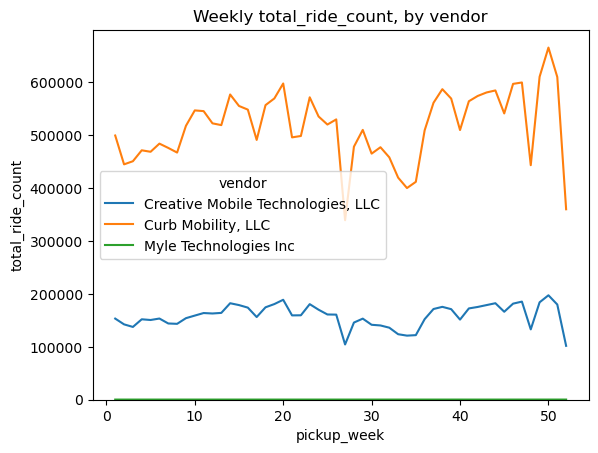

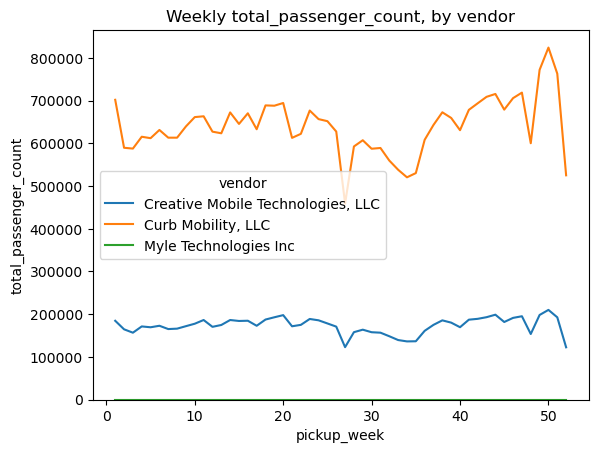

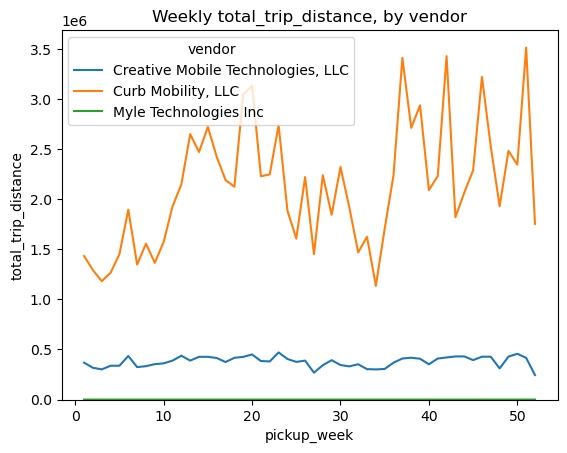

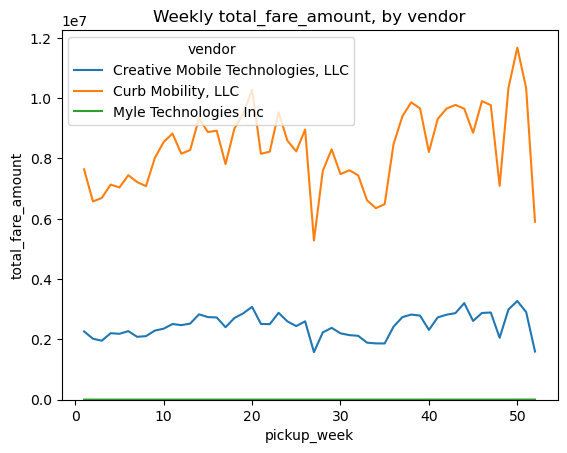

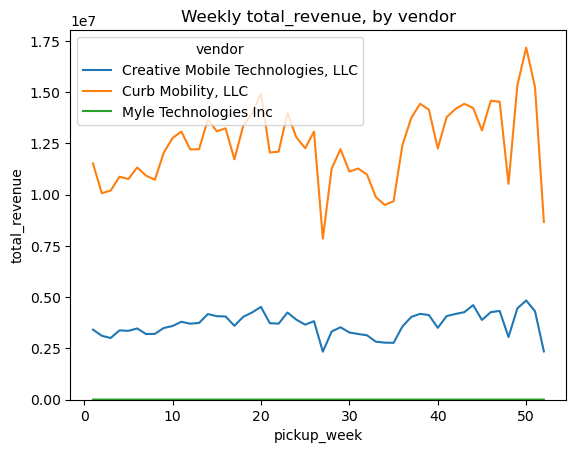

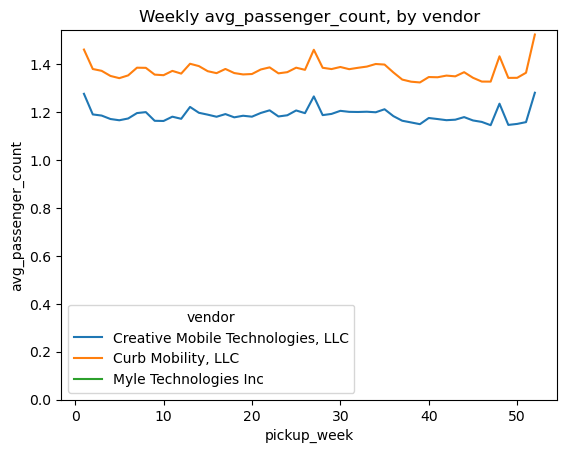

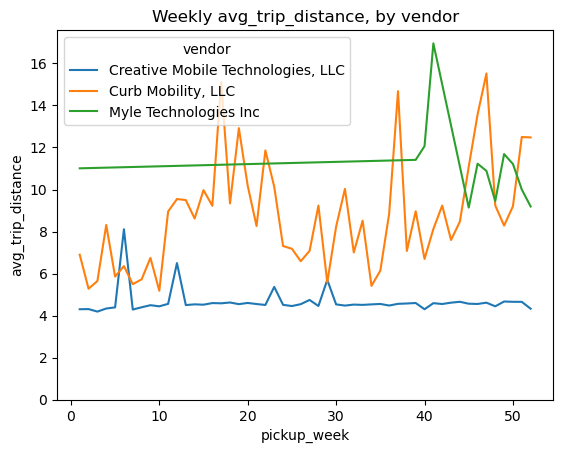

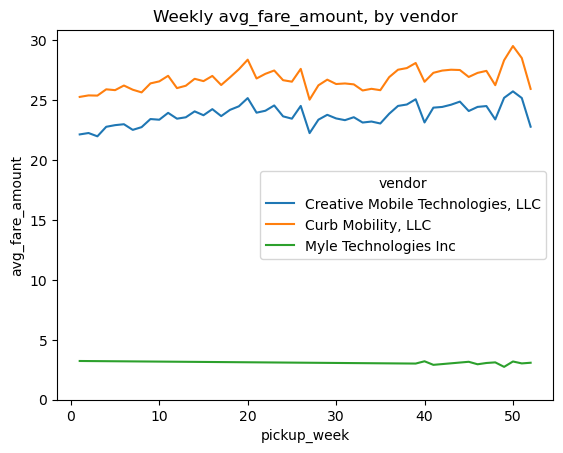

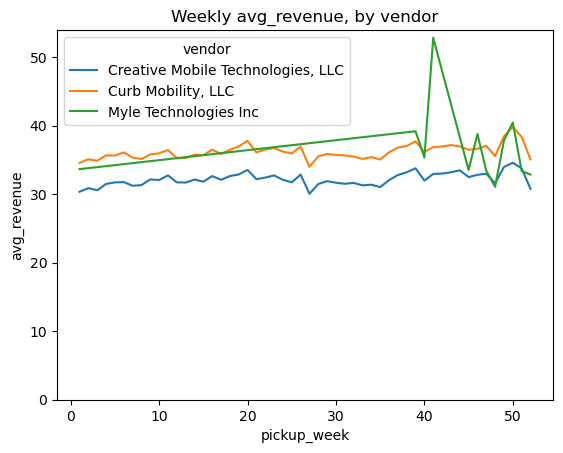

KeyError: 'ratecode'

In [3]:
def sum_weekly(by='vendor', sum='total_ride_count'):
    weekly_counts = df.groupby(by=['pickup_week', by], as_index=False)[sum].sum()
    sns.lineplot(data=weekly_counts, x='pickup_week', y=sum, hue=by)
    plt.title(f"Weekly {sum}, by {by}")
    plt.ylim(bottom=0)
    plt.show()

def avg_weekly(by='vendor', avg='avg_revenue'):
    weekly_counts = df.groupby(by=['pickup_week', by], as_index=False)[avg].mean()
    sns.lineplot(data=weekly_counts, x='pickup_week', y=avg, hue=by)
    plt.title(f"Weekly {avg}, by {by}")
    plt.ylim(bottom=0)
    plt.show()

for category in ['vendor', 'ratecode', 'payment_type']:
    sum_weekly(by=category, sum='total_ride_count')
    sum_weekly(by=category, sum='total_passenger_count')
    sum_weekly(by=category, sum='total_trip_distance')
    sum_weekly(by=category, sum='total_fare_amount')
    sum_weekly(by=category, sum='total_revenue')
    avg_weekly(by=category, avg='avg_passenger_count')
    avg_weekly(by=category, avg='avg_trip_distance')
    avg_weekly(by=category, avg='avg_fare_amount')
    avg_weekly(by=category, avg='avg_revenue')

# Preprocess: organise features

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category
# Not sure why this changes from typecasting in `dataset.clean()`
df = df.astype({
    'vendor': 'category',
    # 'ratecode': 'category',
    'pickup_zone': 'category',
    'dropoff_zone': 'category',
    'route': 'category',
})

# Remove waste columns
df = df.drop(columns=[
    'pickup_week',
    'pickup_day',
    'total_passenger_count',  
    'avg_passenger_count',    
    'total_trip_distance',    
    'avg_trip_distance',      
    'total_fare_amount',      
    'avg_fare_amount',        
    'total_extra',            
    'avg_extra',              
    'total_mta_tax',          
    'avg_mta_tax',            
    'total_tip_amount',       
    'avg_tip_amount',         
    'total_tolls_amount',     
    'avg_tolls_amount',       
    'total_impr_surcharge',
    'avg_impr_surcharge',     
    'total_revenue',          
    'avg_revenue',            
    'total_airport_fee',      
    'avg_airport_fee',       
])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2887808 entries, 10 to 2887836
Data columns (total 15 columns):
 #   Column                Dtype   
---  ------                -----   
 0   pickup_year           int32   
 1   pickup_month          int32   
 2   pickup_dow            int32   
 3   pickup_service_zone   category
 4   pickup_zone           category
 5   dropoff_service_zone  category
 6   dropoff_zone          category
 7   route                 category
 8   service_route         category
 9   vendor                category
 10  total_ride_count      int64   
 11  High                  float64 
 12  Low                   float64 
 13  Precip                float64 
 14  Snow                  float64 
dtypes: category(7), float64(4), int32(3), int64(1)
memory usage: 190.7 MB


# Preprocess: Split data

In [6]:
# Onehot encode the following:
#
#  4   pickup_service_zone    category
#  5   pickup_zone            category  
#  6   dropoff_service_zone   category
#  7   dropoff_zone           category  
#  8   route                  category  
#  9   service_route          category  
#  10  vendor                 category  
#  11  ratecode               category  [NOT USED]
#  12  payment_type           category  [NOT USED]
#
# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    'pickup_service_zone',
    'dropoff_service_zone',
    'service_route',
    'vendor',
    'pickup_dow',
    # 'ratecode',
    # 'payment_type',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'dropoff_zone',
    'route'
]

# Split `y` BEFORE pipeline
y = df['total_ride_count']
X = df.drop(columns=['total_ride_count'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # DEPRECATED: returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

# Train

In [7]:
from sklearn.ensemble import RandomForestRegressor

# ### Initial model
#
# rf =  RandomForestRegressor(
#     random_state=seed,
#     n_estimators=75,
#     max_depth=10
# )

### Fine-tuned model
rf = RandomForestRegressor(
    random_state=seed,
    n_estimators=75,
    min_samples_leaf=2, # weird clustering around `25`0 & `400` predictions without this
    max_depth=25
)
rf.fit(X_train, y_train)

,n_estimators,75
,criterion,'squared_error'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Validate

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Collection of regression scores
#
# 1. Mean Abs Err: 
# 2. Mean Sq Err:
# 3. R Sq: percentage of variance explained
# 4. Residuals plot
# 5. Actual vs. Predicted plot
def analysis(y_true, y_pred):
    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    print(f"Mean Absolute Error: \t{mae:.4f}")

    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    print(f"Mean Squared Error: \t{mse:.4f}")

    # R squared
    r2 = r2_score(y_true, y_pred)
    print(f"R squared: \t\t{r2:.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Residuals
    residuals = y_true - y_pred
    ax[0].scatter(y_pred, residuals, alpha=.4)
    ax[0].axhline(0, color='black', linestyle='--')
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Residuals")
    ax[0].set_title("Residuals")

    # Actual vs predicted
    ax[1].scatter(y_true, y_pred, alpha=.4)
    ax[1].set_xlabel("Actual")
    ax[1].set_ylabel("Predicted")
    ax[1].set_title("Actual vs. Predicted")

Mean Absolute Error: 	1.7887
Mean Squared Error: 	15.5054
R squared: 		0.9754


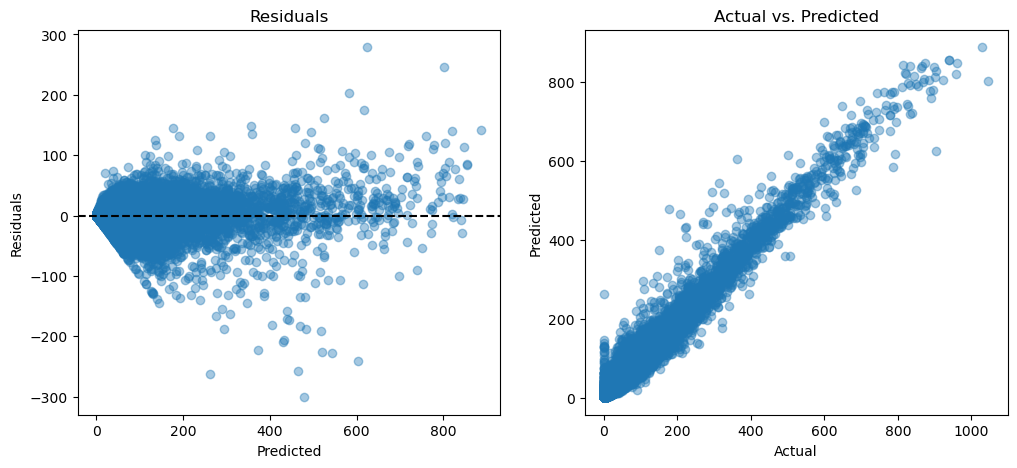

In [9]:
training_predictions = rf.predict(X_train)
analysis(y_train, training_predictions)

Mean Absolute Error: 	2.8348
Mean Squared Error: 	39.7945
R squared: 		0.9376


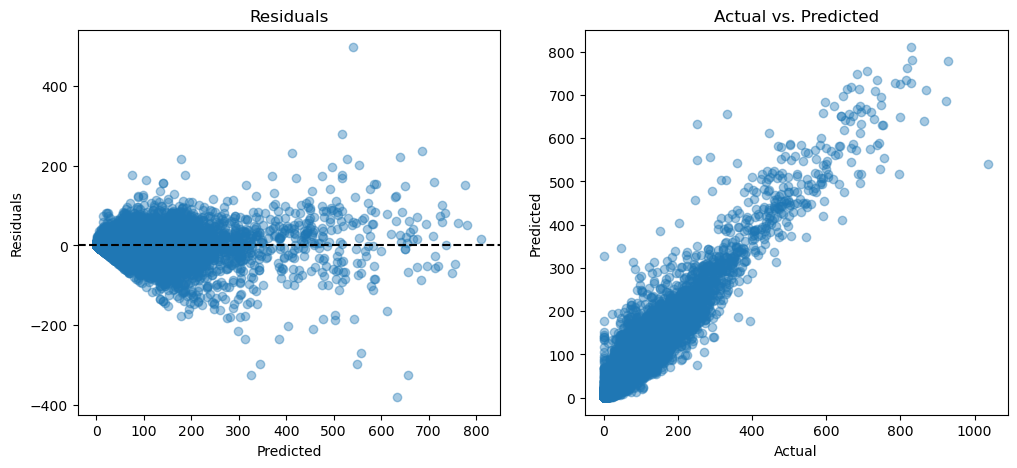

In [10]:
validation_predictions = rf.predict(X_val)
analysis(y_val, validation_predictions)

                                             feature    importance
26                                    ordinal__route  3.710084e-01
25                             ordinal__dropoff_zone  2.762951e-01
13  onehot__service_route_Yellow Zone to Yellow Zone  9.473981e-02
24                              ordinal__pickup_zone  8.434166e-02
15                 onehot__vendor_Curb Mobility, LLC  6.918491e-02
23                              onehot__pickup_dow_6  1.944497e-02
30                                    remainder__Low  1.733989e-02
28                           remainder__pickup_month  1.581230e-02
22                              onehot__pickup_dow_5  1.504763e-02
29                                   remainder__High  1.226752e-02
31                                 remainder__Precip  6.751038e-03
17                              onehot__pickup_dow_0  5.582256e-03
21                              onehot__pickup_dow_4  3.347131e-03
10     onehot__service_route_Yellow Zone to Airports  2.363174

<Figure size 1200x1200 with 0 Axes>

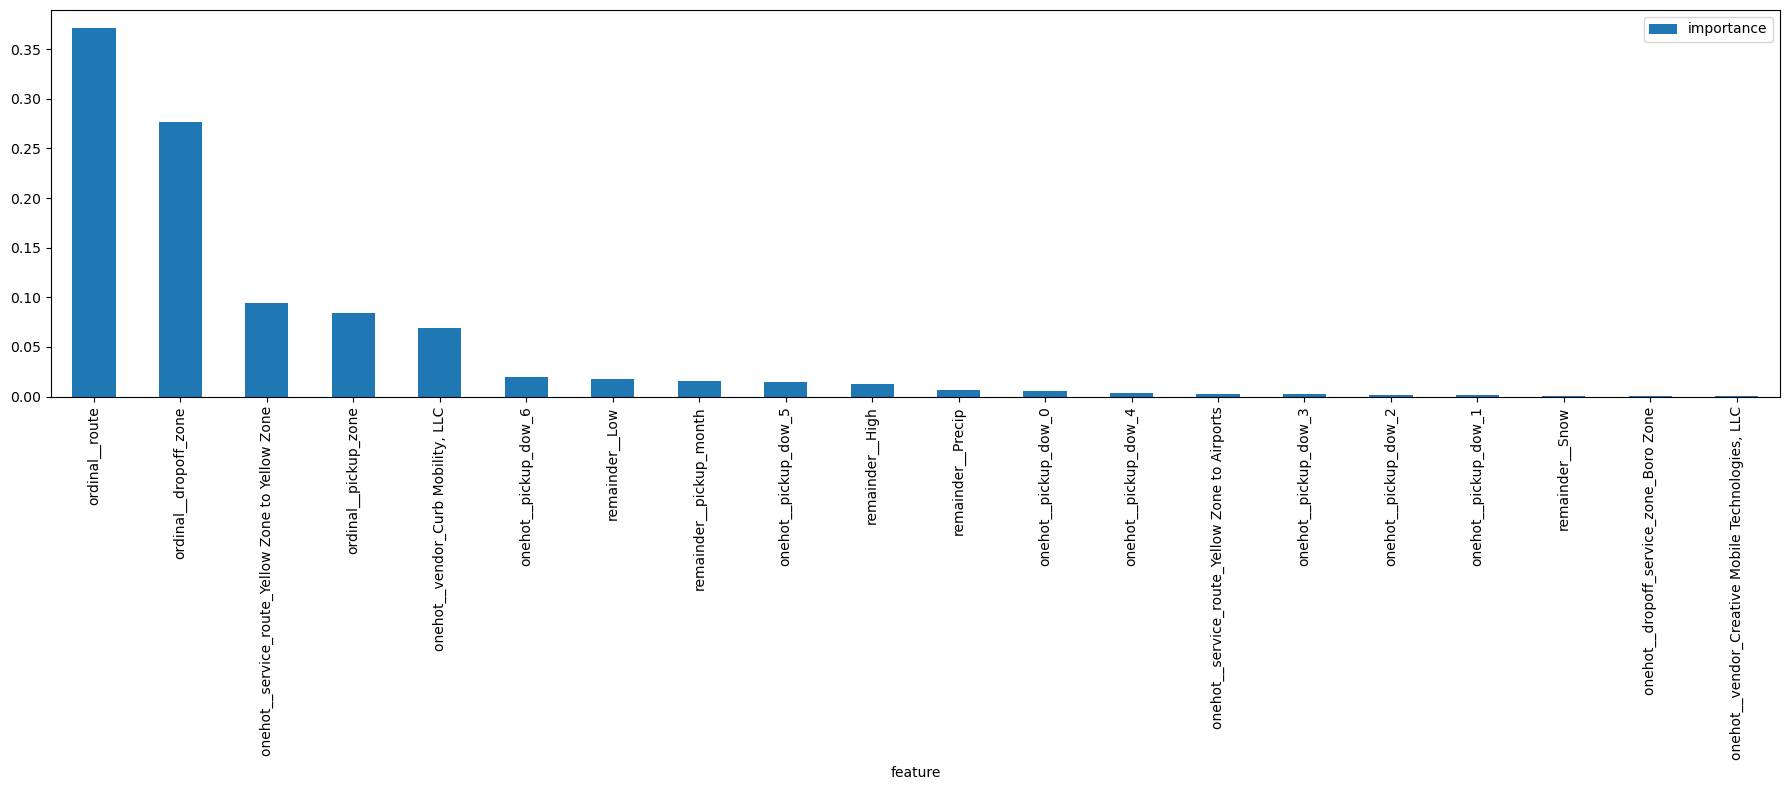

In [11]:
feature_names = pipeline.get_feature_names_out()
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feat_df)

plt.figure(figsize=(12,12))
feat_df.head(20).plot(kind='bar', x='feature', y='importance', figsize=(18, 8))
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

# Test

Mean Absolute Error: 	2.8435
Mean Squared Error: 	41.5215
R squared: 		0.9372


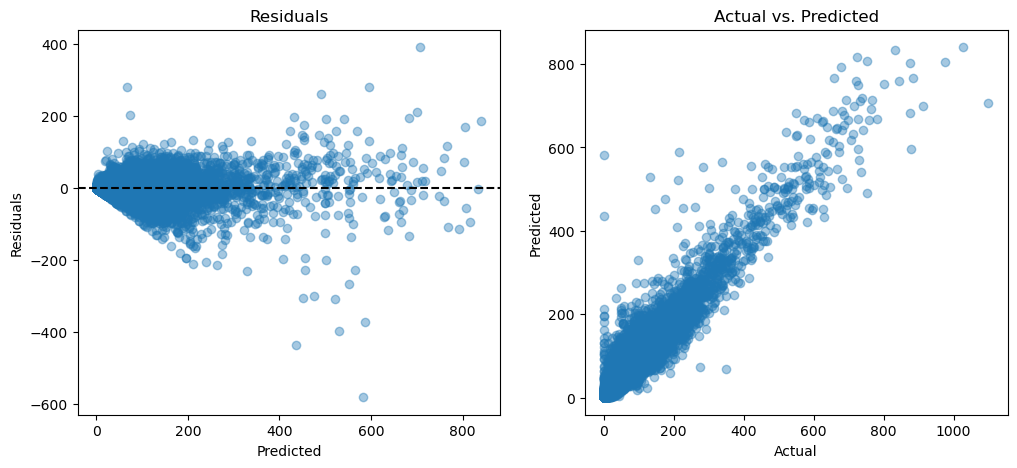

In [12]:
test_predictions = rf.predict(X_test)
analysis(y_test, test_predictions)